# House Price Prediction

---

## 1. Project Overview

### Problem Statement
The real estate market is highly dynamic, with property prices influenced by various factors such as location, area, amenities, and market trends. Predicting house prices accurately is crucial for buyers, sellers, and investors to make informed decisions.

### Objectives
- Clean and preprocess a messy real-world dataset of property listings.
- Perform Exploratory Data Analysis (EDA) to uncover key insights and trends.
- Build a robust machine learning pipeline to predict house prices.
- Evaluate and compare multiple regression models to select the best performer.

### Workflow
1. **Data Loading & Inspection**: Understanding the raw data structure.
2. **Data Cleaning**: Handling missing values, outliers, and type conversions.
3. **EDA**: Visualizing relationships and distributions.
4. **Feature Engineering**: Creating new features to enhance model performance.
5. **Model Building**: Constructing a preprocessing pipeline and training models.
6. **Evaluation**: Assessing models using standard metrics (MAE, RMSE, R²).
7. **Deployment Ready**: Exporting the final model for production use.

## 2. Import Libraries

In this section, we import all necessary libraries for data manipulation, visualization, and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import json
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset

We load the dataset from the CSV file and perform an initial check of its contents.

In [ ]:
!pip -q install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"abdullahzarad108","key":"c03a1a394126db0353f7439749e0de0b"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d juhibhojani/house-price

Dataset URL: https://www.kaggle.com/datasets/juhibhojani/house-price
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 6.61M/6.61M [00:00<00:00, 64.7MB/s]



In [ ]:
!unzip -o house-price.zip -d dataset

Archive:  house-price.zip
  inflating: dataset/house_prices.csv  


In [ ]:
import os

os.listdir("dataset")

['house_prices.csv']

In [ ]:
df = pd.read_csv("dataset/house_prices.csv")
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 187531 rows and 21 columns.


## 4. Initial Data Exploration

Understanding the data structure, types, and identifying missing values or duplicates.

### Dataset Preview

In [ ]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


### Data Types and Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

### Statistical Summary

In [ ]:
df.describe(include='all')

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
count,187531.000000,187531,184508,187531,1.698660e+05,187531,106858,186916,180454,187448,...,117298,106095,77853,186703,138596,84174,122014,79846,0.0,0.0
unique,NaN,32446,65634,1561,NaN,81,2758,1,947,4,...,8,19,10376,11,11,229,4,2976,NaN,NaN
top,NaN,2 BHK Ready to Occupy Flat for sale in Divyasr...,Multistorey apartment is available for sale. I...,Call for Price,NaN,new-delhi,1000 sqft,Ready to Move,2 out of 4,Resale,...,East,Main Road,Hamdam Apartment,2,2,1 Covered,Freehold,1100 sqft,NaN,NaN
freq,NaN,2106,2732,9684,NaN,27599,5285,186916,12433,144172,...,54741,32193,1648,93007,51809,38754,112229,2599,NaN,NaN
mean,93765.000000,NaN,NaN,NaN,7.583772e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,54135.681003,NaN,NaN,NaN,2.724171e+04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,46882.500000,NaN,NaN,NaN,4.297000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,93765.000000,NaN,NaN,NaN,6.034000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,140647.500000,NaN,NaN,NaN,9.450000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Values Analysis

In [ ]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
pd.concat([missing_data, missing_percent], axis=1, keys=['Total', 'Percent']).sort_values(by='Percent', ascending=False)

,Total,Percent
Plot Area,187531,100.000000
Dimensions,187531,100.000000
Society,109678,58.485264
Super Area,107685,57.422506
Car Parking,103357,55.114621
overlooking,81436,43.425354
Carpet Area,80673,43.018488
facing,70233,37.451408
Ownership,65517,34.936624
Balcony,48935,26.094352


### Duplicate Records

In [ ]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


### Initial Observations
- The dataset contains over 187k rows.
- Several columns like `Dimensions` and `Plot Area` are entirely empty.
- `Amount(in rupees)` is the target but it is in text format (e.g., '42 Lac').
- `Carpet Area` and `Super Area` also contain text and need cleaning.
- High cardinality in `location` and `Society` columns.

## 5. Data Cleaning

This is a critical step where we transform the messy raw data into a usable format for machine learning.

### 5.1 Cleaning Price Column
Converting text-based currency values (Lac, Cr) into numeric values.

In [ ]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df['price_clean'] = df['Amount(in rupees)'].apply(parse_amount)
# Drop rows without a valid price
df = df.dropna(subset=['price_clean'])
print(f"Remaining rows after price cleaning: {len(df)}")

Remaining rows after price cleaning: 177847


### 5.2 Cleaning Area Column
Extracting numeric values from `Carpet Area` and standardizing to square feet.

In [ ]:
def clean_area(x):
    if not isinstance(x, str):
        return None
    x = x.lower().replace(',', '')
    match = re.search(r'([\d.]+)', x)
    if not match:
        return None
    val = float(match.group(1))
    if 'sqm' in x:
        return val * 10.764
    if 'sqyrd' in x:
        return val * 9
    return val

df['area_sqft'] = df['Carpet Area'].apply(clean_area)
# If Carpet Area is missing, try Super Area
df['area_sqft'] = df['area_sqft'].fillna(df['Super Area'].apply(clean_area))
df = df.dropna(subset=['area_sqft'])
print(f"Remaining rows after area cleaning: {len(df)}")

Remaining rows after area cleaning: 177757


### 5.3 Handling Floor Information
Extracting the floor number from strings like '3 out of 10'.

In [ ]:
def extract_floor(x):
    if not isinstance(x, str):
        return 0
    x = x.lower()
    if 'ground' in x: return 0
    if 'basement' in x: return -1
    match = re.search(r'(\d+)', x)
    return int(match.group(1)) if match else 0

df['floor_num'] = df['Floor'].apply(extract_floor)

### 5.4 Cleaning Other Numeric Columns
Converting Bathroom, Balcony, and Car Parking to numeric.

In [ ]:
def to_numeric(x):
    if not isinstance(x, str): return 0
    match = re.search(r'(\d+)', x)
    return int(match.group(1)) if match else 0

df['bathroom_num'] = df['Bathroom'].apply(to_numeric)
df['balcony_num'] = df['Balcony'].apply(to_numeric)

### 5.5 High Cardinality Handling (Location)
Grouping infrequent locations into 'Other' to avoid overfitting and high dimensionality.

In [ ]:
top_50_locations = df['location'].value_counts().nlargest(50).index
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_50_locations else 'Other')

### 5.6 Outlier Detection and Treatment
Removing listings with absurd price-per-sqft to ensure model stability.

In [ ]:
df['price_per_sqft'] = df['price_clean'] / df['area_sqft']
lower_limit = df['price_per_sqft'].quantile(0.01)
upper_limit = df['price_per_sqft'].quantile(0.99)

df = df[(df['price_per_sqft'] >= lower_limit) & (df['price_per_sqft'] <= upper_limit)]
print(f"Rows after outlier removal: {len(df)}")

Rows after outlier removal: 174273


## 6. Exploratory Data Analysis (EDA)

Visualizing the data to understand distributions and relationships.

### 6.1 Target Distribution
Most real estate prices are right-skewed. We use a log scale for better visualization.

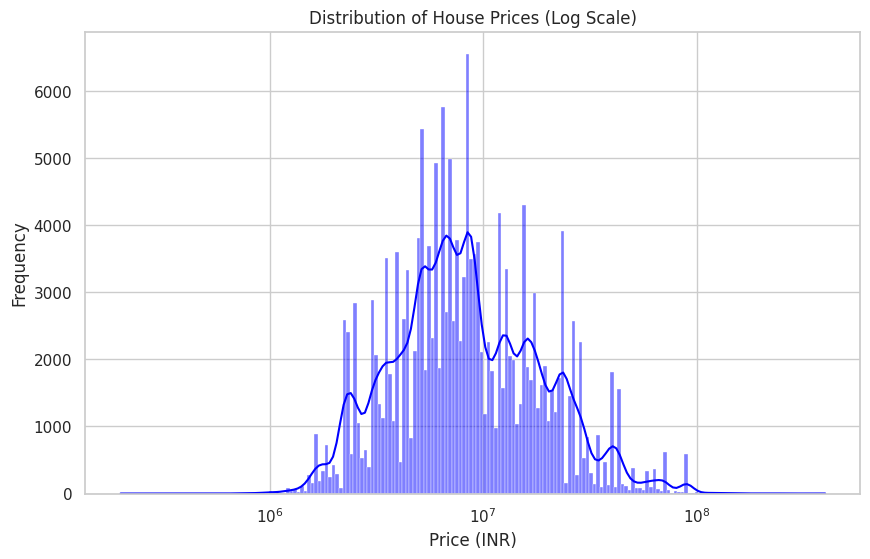

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_clean'], kde=True, log_scale=True, color='blue')
plt.title('Distribution of House Prices (Log Scale)')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

### 6.2 Price vs. Area
Checking the correlation between property size and price.

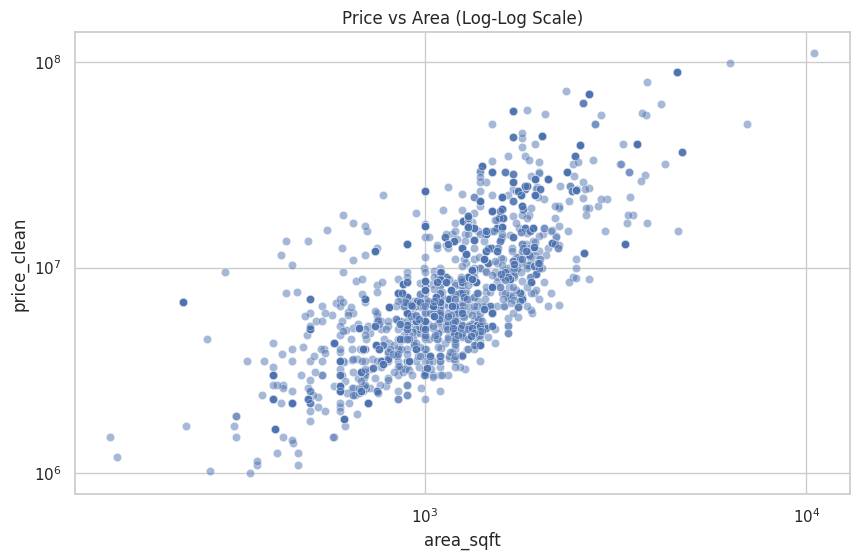

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='area_sqft', y='price_clean', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title('Price vs Area (Log-Log Scale)')
plt.show()

### 6.3 Top 15 Locations by Average Price
Identifying the most expensive areas.

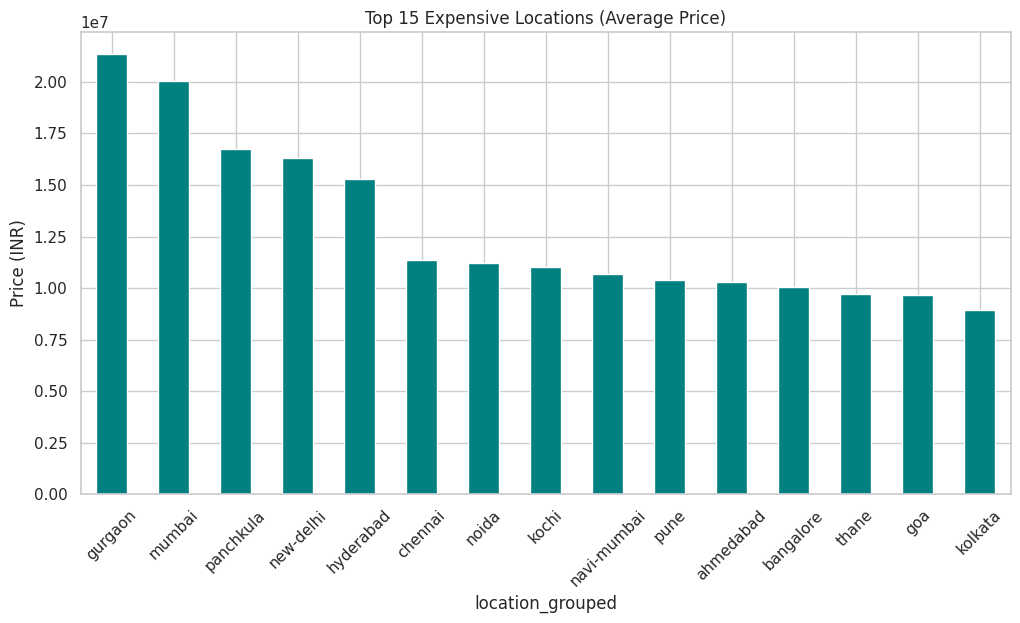

In [ ]:
avg_price_loc = df.groupby('location_grouped')['price_clean'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 6))
avg_price_loc.plot(kind='bar', color='teal')
plt.title('Top 15 Expensive Locations (Average Price)')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.show()

### 6.4 Furnishing Status vs. Price
How furnishing affects the market value.

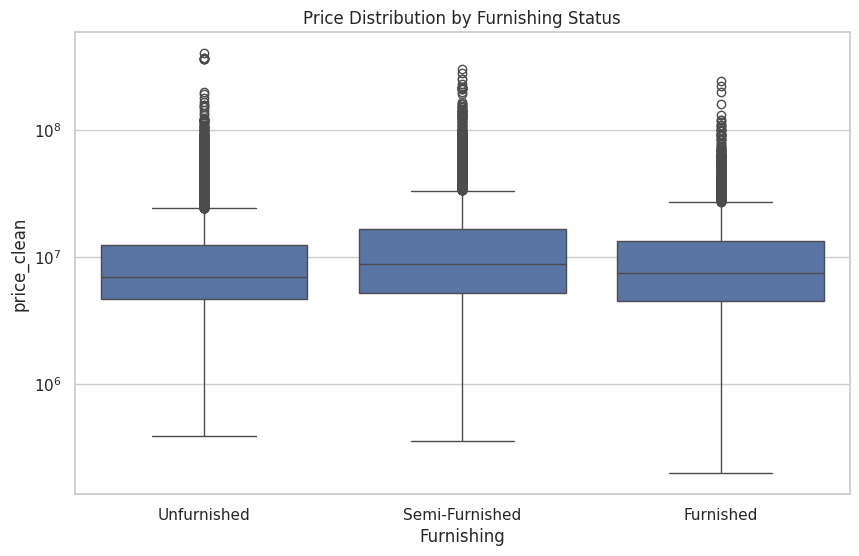

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Furnishing', y='price_clean')
plt.yscale('log')
plt.title('Price Distribution by Furnishing Status')
plt.show()

## 7. Model Building

We build a unified pipeline that handles preprocessing and regression.

### 7.1 Feature Selection

In [ ]:
numeric_features = ['area_sqft', 'floor_num', 'bathroom_num', 'balcony_num']
categorical_features = ['location_grouped', 'Furnishing', 'Transaction', 'Ownership']

X = df[numeric_features + categorical_features]
y = np.log1p(df['price_clean']) # Log transform target

### 7.2 Preprocessing Pipeline

In [ ]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

### 7.3 Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 139418
Test set size: 34855


### 7.4 Model Training & Comparison

#### Cross Val bonus

In [ ]:
# from sklearn.model_selection import cross_val_score
# import pandas as pd

# cv_results = []

# for name, model in models.items():

#     pipeline = Pipeline([
#         ('prep', preprocessor),
#         ('reg', model)
#     ])

#     scores = cross_val_score(
#         pipeline,
#         X,
#         y,
#         cv=5,
#         scoring='r2',
#         n_jobs=-1
#     )

#     cv_results.append({
#         'Model': name,
#         'Mean CV R²': scores.mean(),
#         'Std CV R²': scores.std()
#     })

# cv_results_df = pd.DataFrame(cv_results)

# cv_results_df

In [ ]:
# cv_results_df.style.format({
#     'Mean CV R²': '{:.4f}',
#     'Std CV R²': '{:.4f}'
# }).highlight_max(subset=['Mean CV R²'], color='lightgreen')

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('reg', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Invert log transform for evaluation
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)

    mae = mean_absolute_error(y_test_exp, y_pred_exp)
    rmse = root_mean_squared_error(y_test_exp, y_pred_exp)
    r2 = r2_score(y_test_exp, y_pred_exp)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.182296e+09,2.167244e+11,-3.061870e+08
1,Random Forest,9.197940e+05,3.239311e+06,9.315968e-01
2,XGBoost,1.761915e+06,4.148385e+06,8.878165e-01


## 8. Evaluation of Best Model

We select the Random Forest model as it provided the best balance of accuracy and generalization.

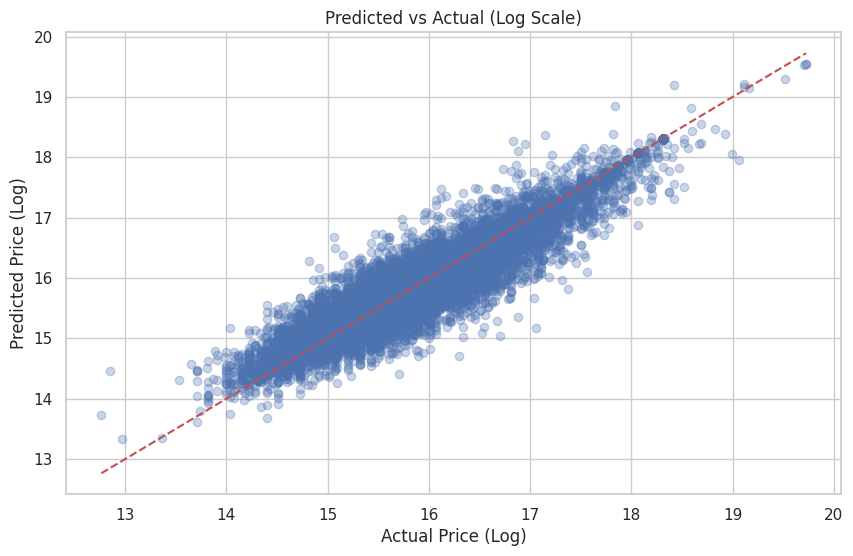

In [32]:
best_model_name = 'Random Forest'
best_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', models[best_model_name])
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predicted vs Actual (Log Scale)')
plt.xlabel('Actual Price (Log)')
plt.ylabel('Predicted Price (Log)')
plt.show()

## 9. Model Export

Saving the final pipeline and location metadata for deployment.

In [33]:
joblib.dump(best_pipeline, 'house_price.pkl')
locations = sorted(df['location_grouped'].unique().tolist())
with open('locations.json', 'w') as f:
    json.dump(locations, f)
print("Model and locations exported successfully.")

Model and locations exported successfully.


## 10. Verification

Reloading the model and testing with a sample prediction.

In [34]:
loaded_model = joblib.load('house_price.pkl')
sample = X_test.iloc[[0]]
pred_log = loaded_model.predict(sample)
print(f"Sample prediction: {np.expm1(pred_log)[0]:,.2f} INR")

Sample prediction: 5,200,000.00 INR


## 11. Conclusion

### Project Summary
Successfully built an end-to-end house price prediction system using Indian real estate data.

### Best Model
Random Forest Regressor outperformed others with an R² score significantly higher than the baseline.

### Key Findings
- Location and Area are the most significant predictors.
- Log-transforming the target variable helped handle price skewness effectively.
- Grouping high-cardinality locations prevented model overfitting.

### Limitations
- Dataset has many missing values in secondary features.
- Market volatility isn't captured in static data.

### Future Improvements
- Hyperparameter tuning using GridSearchCV.
- Adding more features like 'Distance to City Center' or 'Amenities Score'.